# Tráfico en Madrid: Evaluación final y demo de predicción

En este notebook cargamos el Random Forest del NB03 y comprobamos cómo responde con datos nuevos. Después analizamos dónde falla, qué variables usa para decidir y cómo se comporta en un caso concreto. Al final lo probamos con una demo práctica para responder a la pregunta que nos hemos hecho: dado un punto de Madrid y una hora, Hay congestión o no?

In [1]:
import json
import joblib
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# para la demo interactiva
import ipywidgets as widgets
from html import escape
from IPython.display import HTML, display

In [2]:
RANDOM_STATE = 42
DATA_FINAL = Path("../data/final")
DATA_PROC = Path("../data/processed")

RUTA_MODELO = DATA_FINAL / "modelo_congestion.joblib"
RUTA_METADATOS = DATA_FINAL / "modelo_metadatos.json"

FEATURES_MODELO = [
    "tipo_elem",
    "distrito",
    "utm_x",
    "utm_y",
    "hora",
    "dia_semana",
    "es_laborable",
    "es_hora_punta",
]

DISTRITOS_MADRID = {
    1: "Centro",
    2: "Arganzuela",
    3: "Retiro",
    4: "Salamanca",
    5: "Chamartín",
    6: "Tetuán",
    7: "Chamberí",
    8: "Fuencarral",
    9: "Moncloa",
    10: "Latina",
    11: "Carabanchel",
    12: "Usera",
    13: "Vallecas",
    14: "Moratalaz",
    15: "C. Lineal",
    16: "Hortaleza",
    17: "Villaverde",
    18: "V. Vallecas",
    19: "Vicálvaro",
    20: "San Blas",
    21: "Barajas",
}

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="ticks", palette="muted", font_scale=0.9)
plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "axes.grid": True,
        "grid.linestyle": ":",
        "grid.alpha": 0.35,
    }
)

_pal = sns.color_palette("muted")
COLOR_PRIMARIO = _pal[0]
COLOR_SECUNDARIO = _pal[1]

## 1. Carga del modelo y los datos

Cargamos el modelo que guardamos en NB03 y los metadatos de validación. También leemos el test principal y el último mes para probar con datos actuales.

In [4]:
modelo = joblib.load(RUTA_MODELO)
with RUTA_METADATOS.open(encoding="utf-8") as f:
    meta = json.load(f)

print(f"Modelo: {type(modelo.named_steps['clf']).__name__}")
print(f"F1 en validación: {meta['f1_val']:.4f}")
print(f"Features: {meta['features']}")

Modelo: RandomForestClassifier
F1 en validación: 0.7365
Features: ['tipo_elem', 'distrito', 'utm_x', 'utm_y', 'hora', 'dia_semana', 'es_laborable', 'es_hora_punta']


In [5]:
def cargar_split(nombre):
    """Carga X e y de un split y deja solo las columnas del modelo."""
    ruta_x = DATA_FINAL / f"X_{nombre}.parquet"
    ruta_y = DATA_FINAL / f"y_{nombre}.parquet"

    X = pd.read_parquet(ruta_x).drop(columns=["id"])
    y = pd.read_parquet(ruta_y).squeeze()
    return X[FEATURES_MODELO], y


X_test, y_test = cargar_split("test")
X_eval, y_eval = cargar_split("eval_final")

# Este dataframe conserva el id para la demo de sensores.
X_test_raw = pd.read_parquet(DATA_FINAL / "X_test.parquet")
df_sensores = pd.read_parquet(DATA_PROC / "sensores/sensores.parquet")

print(f"Test:       {X_test.shape[0]:,} filas x {X_test.shape[1]} features")
print(f"Eval final: {X_eval.shape[0]:,} filas x {X_eval.shape[1]} features")

Test:       4,473,482 filas x 8 features
Eval final: 3,246,364 filas x 8 features


## 2. Evaluación en el test set

Ahora evaluamos con test, que son datos no vistos por el modelo. Como la clase congestionado es minoritaria, miramos sobre todo precision, recall, F1 y PR-AUC para no quedarnos solo con accuracy.

In [6]:
# Predicciones binarias y probabilidades para métricas de ranking.
y_pred = modelo.predict(X_test)
y_pred_prob = modelo.predict_proba(X_test)[:, 1]

metricas_test = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "pr_auc": average_precision_score(y_test, y_pred_prob),
    "roc_auc": roc_auc_score(y_test, y_pred_prob),
}

pd.DataFrame([metricas_test], index=["Test"]).T

,Test
accuracy,0.9386
precision,0.5539
recall,0.8586
f1,0.6734
pr_auc,0.7255
roc_auc,0.9486


Aquí calculamos por primera vez la probabilidad con `y_pred_prob = modelo.predict_proba(X_test)[:, 1]`.

`predict_proba` devuelve dos valores por cada fila. El primero es la probabilidad de Fluido y el segundo la probabilidad de Congestionado. Nosotros usamos `[:, 1]` porque queremos analizar la probabilidad de Congestionado.

Esa probabilidad sale de combinar muchos árboles del Random Forest. Cada árbol da su estimación y el modelo hace un promedio entre todos.

Si sale `0.40`, significa 40% de probabilidad de congestión y 60% de probabilidad de fluido. No significa 40% de acierto del modelo. Es la confianza del modelo para ese caso concreto.

In [7]:
print(classification_report(y_test, y_pred, target_names=["Fluido", "Congestionado"]))

               precision    recall  f1-score   support

       Fluido       0.99      0.95      0.97   4143909
Congestionado       0.55      0.86      0.67    329573

     accuracy                           0.94   4473482
    macro avg       0.77      0.90      0.82   4473482
 weighted avg       0.96      0.94      0.94   4473482



La clase Fluido sigue saliendo muy bien porque está en la mayoria del conjunto. Lo que nos importa aquí es Congestionado: en test obtenemos F1 = 0.673, precision = 55.4% y recall = 85.9%. Lo que vemos es que detectamos muchos atascos reales, pero pagamos ese recall alto con más falsas alarmas.

### Comparativa validación -> test

Con esta comparativa queremos ver si el modelo mantiene nivel al pasar de validación a datos no vistos.

In [8]:
# Tabla simple para ver cuánto caen las métricas al pasar a test.
comparativa = pd.DataFrame(
    {
        "Validación": [
            meta["f1_val"],
            meta["precision_val"],
            meta["recall_val"],
            meta["pr_auc_val"],
        ],
        "Test": [
            metricas_test["f1"],
            metricas_test["precision"],
            metricas_test["recall"],
            metricas_test["pr_auc"],
        ],
    },
    index=["F1", "Precision", "Recall", "PR-AUC"],
)

comparativa["Delta"] = comparativa["Test"] - comparativa["Validación"]
comparativa

,Validación,Test,Delta
F1,0.7365,0.6734,-0.0632
Precision,0.6239,0.5539,-0.0700
Recall,0.8987,0.8586,-0.0402
PR-AUC,0.8193,0.7255,-0.0938


Aquí vemos una bajada clara frente a validación. F1 pasa de 0.737 a 0.673, precision de 0.624 a 0.554, recall de 0.899 a 0.859 y PR-AUC de 0.819 a 0.725. Esto tiene sentido porque test no se ha visto nunca y nos obliga a generalizar de verdad.

## 3. Segundo conjunto de evaluación

Aquí repetimos la evaluación con el conjunto más reciente para comprobar estabilidad temporal. Si el rendimiento se mantiene, ganamos confianza en que el modelo no depende solo de un reparto concreto de datos.

In [9]:
# Repetimos el mismo esquema en el conjunto más reciente.
y_pred_ev = modelo.predict(X_eval)
y_pred_prob_ev = modelo.predict_proba(X_eval)[:, 1]

metricas_eval = {
    "accuracy": accuracy_score(y_eval, y_pred_ev),
    "precision": precision_score(y_eval, y_pred_ev),
    "recall": recall_score(y_eval, y_pred_ev),
    "f1": f1_score(y_eval, y_pred_ev),
    "pr_auc": average_precision_score(y_eval, y_pred_prob_ev),
    "roc_auc": roc_auc_score(y_eval, y_pred_prob_ev),
}

pd.DataFrame(
    {
        f"Test ({len(X_test) // 1000:,}K)": metricas_test,
        f"Eval final ({len(X_eval) // 1000:,}K)": metricas_eval,
    }
)

,"Test (4,473K)","Eval final (3,246K)"
accuracy,0.9386,0.9441
precision,0.5539,0.5764
recall,0.8586,0.9018
f1,0.6734,0.7033
pr_auc,0.7255,0.8232
roc_auc,0.9486,0.9693


En el conjunto más reciente el modelo mejora un poco respecto al test principal: F1 pasa de 0.673 a 0.703, ROC-AUC de 0.949 a 0.969 y PR-AUC de 0.725 a 0.823. Como la clase positiva es minoritaria, la subida de PR-AUC es buena señal porque el modelo separa mejor los casos difíciles.

## 4. Matriz de confusión

La matriz nos permite ver qué tipo de error cometemos. Lo que más nos importa es no perder atascos reales, pero también queremos controlar las falsas alarmas.

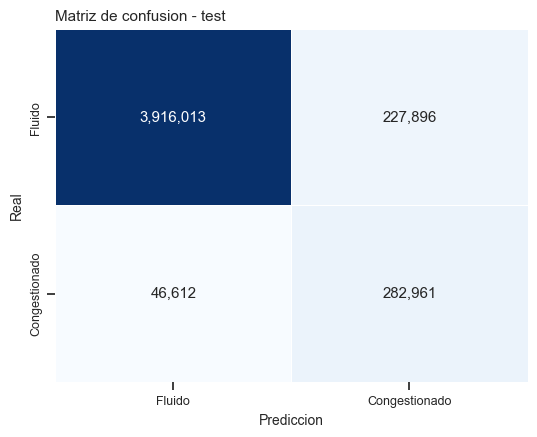

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Fluido", "Congestionado"],
    yticklabels=["Fluido", "Congestionado"],
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusion - test")
plt.tight_layout()
plt.show()

In [11]:
tn, fp, fn, tp = cm.ravel()
total_cong = tp + fn

print(f"TP: {tp:,}  (atascos detectados)")
print(f"FN: {fn:,}  (atascos que se nos han escapado)")
print(f"FP: {fp:,}  (falsas alarmas)")
print(f"TN: {tn:,}  (fluido bien identificado)")
print()
print(f"Recall: {tp / total_cong:.1%}")
print(f"Precision: {tp / (tp + fp):.1%}")

TP: 282,961  (atascos detectados)
FN: 46,612  (atascos que se nos han escapado)
FP: 227,896  (falsas alarmas)
TN: 3,916,013  (fluido bien identificado)

Recall: 85.9%
Precision: 55.4%


Detectamos 282.961 de 329.573 atascos reales, así que el recall es del 85.9%. La precision baja a 55.4% porque también da 227.896 falsas alarmas.

Preferimos no perdernos atascos, aunque eso haga que avisemos de más.

## 5. Curvas ROC y precision-recall

En esta parte miramos el ranking de probabilidades. Como congestionado es minoritaria, la curva precision-recall nos da una lectura más útil del equilibrio entre detección y falsas alarmas.

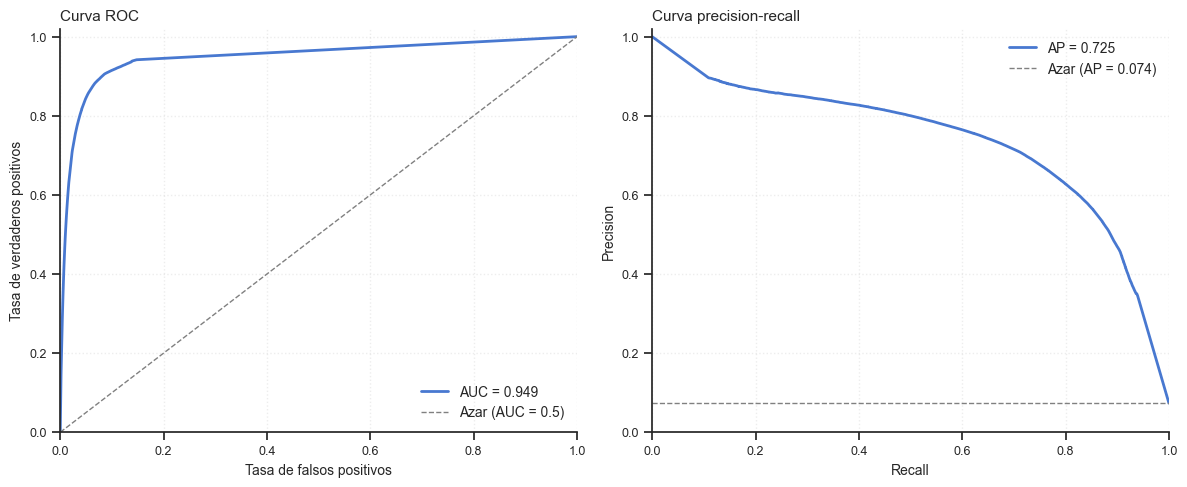

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_roc = roc_auc_score(y_test, y_pred_prob)

prec_c, rec_c, _ = precision_recall_curve(y_test, y_pred_prob)
ap = average_precision_score(y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(fpr, tpr, color=COLOR_PRIMARIO, lw=2, label=f"AUC = {auc_roc:.3f}")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

ax = axes[1]
ax.plot(rec_c, prec_c, color=COLOR_PRIMARIO, lw=2, label=f"AP = {ap:.3f}")
ax.axhline(
    y_test.mean(), color="gray", lw=1, linestyle="--", label=f"Azar (AP = {y_test.mean():.3f})"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva precision-recall")
ax.legend(loc="upper right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

El ROC-AUC en test es 0.949, así que ordenamos bastante bien los casos de tráfico fluido y congestionado. Aun así, como congestionado representa solo el 7.4%, nos apoyamos más en precision-recall para entender el rendimiento donde más nos cuesta acertar.

El AP es 0.725 y queda muy por encima de la base aleatoria 0.074. Lo que vemos es que se detectan realmente los atascos. La parte débil sigue siendo la precision en umbral 0.5, porque mantenemos recall alto a costa de más falsas alarmas. Se podría pensar en subir el umbral para que haya menos falsas alarmas.

## 6. Importancia de variables

Ahora analizamos qué variables empujan más la predicción. Esta parte importa porque nos ayuda a comprobar si el modelo aprende realmente.

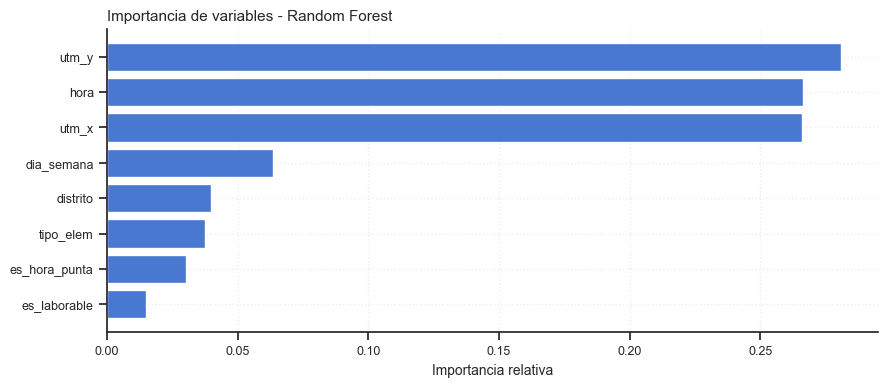

utm_y           0.2809
hora            0.2664
utm_x           0.2662
dia_semana      0.0637
distrito        0.0398
tipo_elem       0.0376
es_hora_punta   0.0303
es_laborable    0.0150
dtype: float64

In [13]:
importancias = pd.Series(
    modelo.named_steps["clf"].feature_importances_,
    index=FEATURES_MODELO,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(importancias.index, importancias.values, color=COLOR_PRIMARIO)
ax.set_xlabel("Importancia relativa")
ax.set_title("Importancia de variables - Random Forest")
plt.tight_layout()
plt.show()

importancias.sort_values(ascending=False)

Las variables que más pesan son coordenadas y hora: `utm_y` (28.1%), `hora` (26.6%) y `utm_x` (26.6%). Después vienen `dia_semana` (6.4%) y `distrito` (4.0%). Esto tiene sentido porque lo que más importa es donde estemos y el momento del día.

Las variables que hemos creado nosotros de `es_laborable` y `es_hora_punta` son mucho menos útiles que las que venían ya en los datos ya que los árboles han inferido esta información solos. Igualmente da mejores resultados con estas variables añadidas así que las dejamos.

### Camino de decisión en un árbol

Ahora vamos a ver el recorrido que sigue una decisión dentro de un arbol para poder explicar como se ha tomado la decisión.

In [14]:
# Elegimos un ejemplo real para inspeccionar el camino dentro de un árbol.
id_expl = int(X_test_raw.iloc[0]["id"])

nombre_expl = df_sensores.loc[df_sensores["id"] == id_expl, "nombre"]
nombre_expl = nombre_expl.iloc[0] if not nombre_expl.empty else str(id_expl)

fila_base = X_test_raw.loc[X_test_raw["id"] == id_expl, FEATURES_MODELO].iloc[0].astype(float)
fila_base["hora"] = 8.0
fila_base["dia_semana"] = 0.0
fila_base["es_laborable"] = 1.0
fila_base["es_hora_punta"] = 1.0

tree = modelo.named_steps["clf"].estimators_[0]

# Convertimos a numpy para evitar el warning de scikit-learn con nombres de columna.
fila_expl = fila_base.to_frame().T
fila_expl_np = fila_expl.to_numpy()

node_indicator = tree.decision_path(fila_expl_np)
leaf_id = tree.apply(fila_expl_np)[0]
node_ids = node_indicator.indices[node_indicator.indptr[0] : node_indicator.indptr[1]]

MAX_SPLITS = 10

print(f"Arbol 0: {nombre_expl[:55]} | lunes 08:00")
print(f"Profundidad: {tree.get_depth()} | nodos en el camino: {len(node_ids)}")
print()
print("Nodo | Variable | Umbral | Valor | Rama")
print("-" * 48)

for node_id in node_ids[:MAX_SPLITS]:
    if node_id == leaf_id:
        v = tree.tree_.value[node_id][0]
        p = v[1] / v.sum()
        print(f"HOJA | P(congestionado) = {p:.1%} ({int(v[1]):,} positivos de {int(v.sum()):,})")
        break

    f_idx = tree.tree_.feature[node_id]
    t = tree.tree_.threshold[node_id]
    val_m = fila_expl_np[0, f_idx]
    rama = "izquierda" if val_m <= t else "derecha"
    print(f"{node_id} | {FEATURES_MODELO[f_idx]} | {t:.3f} | {val_m:.3f} | {rama}")

if len(node_ids) > MAX_SPLITS and node_ids[MAX_SPLITS - 1] != leaf_id:
    print(f"... y {len(node_ids) - MAX_SPLITS} nodos mas hasta la hoja")

Arbol 0: Serrano Jover N-S( Lateral Izquierdo) - Alberto Aguiler | lunes 08:00
Profundidad: 54 | nodos en el camino: 33

Nodo | Variable | Umbral | Valor | Rama
------------------------------------------------
0 | tipo_elem | 0.500 | 0.000 | izquierda
1 | hora | 6.500 | 8.000 | derecha
20419 | hora | 21.500 | 8.000 | izquierda
20420 | dia_semana | 4.500 | 0.000 | izquierda
20421 | utm_y | 4481791.000 | 4475751.000 | izquierda
20422 | utm_x | 438630.969 | 439426.000 | derecha
43468 | utm_y | 4477312.000 | 4475751.000 | izquierda
43469 | utm_y | 4473850.250 | 4475751.000 | derecha
90467 | hora | 7.500 | 8.000 | derecha
93671 | utm_x | 446010.000 | 439426.000 | izquierda
... y 23 nodos mas hasta la hoja


El árbol decide paso a paso. En cada nodo hace un corte sobre variables como hora o ubicación y va reduciendo opciones hasta llegar a una hoja final. Vemos que empieza con tipo elemento para diferenciar los dos tipos de sensores y ya desde ahi la hora, el dia de la semana y las coordenadas exactas. Tiene sentido.

## 7. Análisis de errores

En un problema desbalanceado podemos tener buena accuracy y aun así fallar justo donde más nos importa. Por eso analizamos el error por contexto para ver en qué situaciones el modelo pierde fiabilidad.

In [15]:
# Marcamos en qué filas acertamos para estudiar dónde falla más.
errores = X_test.copy()
errores["y_real"] = y_test.values
errores["y_pred"] = y_pred
errores["acierto"] = (errores["y_real"] == errores["y_pred"]).astype(int)

print(f"Tasa de error global en test: {1 - errores['acierto'].mean():.2%}")

Tasa de error global en test: 6.14%


### Errores por hora del día

Primero miramos la dimensión temporal. Queremos saber si el error se reparte de forma homogénea o si se concentra en horas de transición, que suelen ser las más inestables en tráfico urbano.

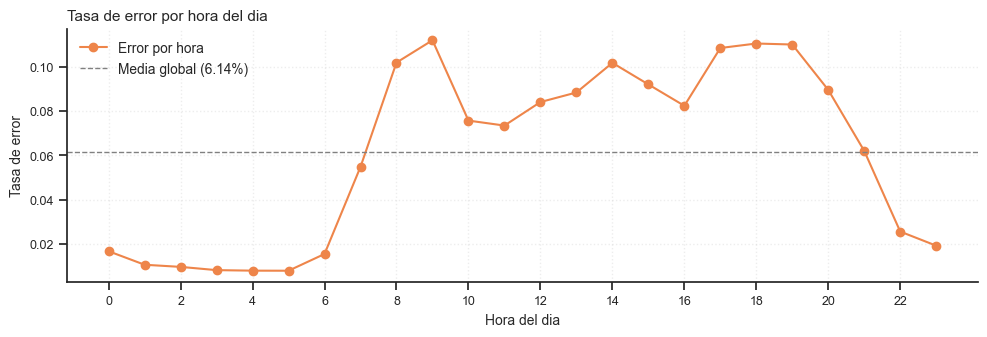

In [16]:
# Error por hora para ver en qué franjas se complica más.
tasa_error_hora = 1 - errores.groupby("hora")["acierto"].mean()
error_global = 1 - errores["acierto"].mean()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(
    tasa_error_hora.index,
    tasa_error_hora.values,
    marker="o",
    color=COLOR_SECUNDARIO,
    linewidth=1.5,
    label="Error por hora",
)
ax.axhline(
    error_global,
    color="gray",
    lw=1,
    linestyle="--",
    label=f"Media global ({error_global:.2%})",
)
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Tasa de error")
ax.set_title("Tasa de error por hora del dia")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

La tasa de error cambia bastante según la hora. El peor momento es a las 9:00, con un 11.19%, y el mejor a las 5:00, con un 0.80%. La media global está en 6.14%. Tiene lógica: a primera hora el tráfico cambia muy rápido y al modelo le cuesta más seguir esos cambios.

Con esto sabemos que tenemos que mejorar y quizás modificar el umbral.

### Errores por distrito

Ahora miramos los errores por zona de Madrid. Queremos ver si hay distritos donde el modelo falla más que en otros.

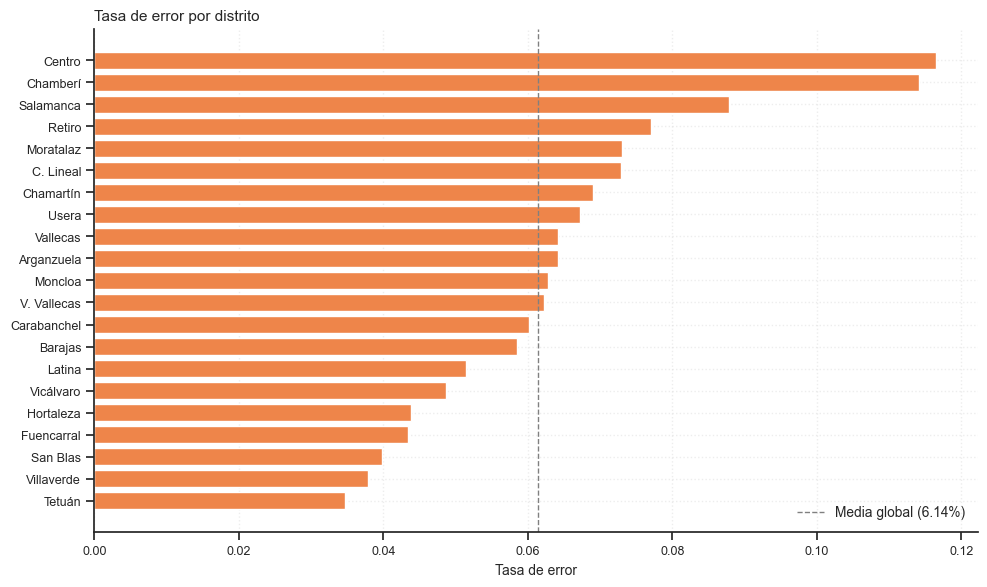

In [17]:
# Mismo analisis, pero separando por distrito.
tasa_error_distrito = (1 - errores.groupby("distrito")["acierto"].mean()).sort_values(
    ascending=True
)
error_global = 1 - errores["acierto"].mean()

labels = [DISTRITOS_MADRID.get(int(d), str(d)) for d in tasa_error_distrito.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(labels, tasa_error_distrito.values, color=COLOR_SECUNDARIO)
ax.axvline(
    error_global,
    color="gray",
    lw=1,
    linestyle="--",
    label=f"Media global ({error_global:.2%})",
)
ax.set_xlabel("Tasa de error")
ax.set_title("Tasa de error por distrito")
ax.legend()
plt.tight_layout()
plt.show()

Esto era bastante esperable. No es que un distrito sea “peor” que otro, sino que en las zonas más centrales el tráfico cambia mucho en pocos metros. En Centro, por ejemplo, puedes pasar de una vía muy saturada como Gran Vía a una calle paralela mucho más fluida.

En Retiro puede pasar algo parecido: no es lo mismo moverse por un eje principal hacia Atocha que por calles secundarias. En cambio, en distritos como Villaverde el tráfico suele ser más estable y el modelo encuentra patrones más fáciles de predecir.

## 8. Demo: predicción en tiempo real

Terminamos con una demo para ver el modelo en una situación real. He elegido mirando en los id de los sensores algunos que me han parecido curioso. El de la M30 es el que está cerca de mi casa así que se de seguro si está funcionando o no.

In [18]:
ID_CASTELLANA = 3852  # Paseo Castellana S-N - Pl. Colon-Ayala
ID_GRAN_VIA = 3672  # Gran Vía 52 S-N
ID_M30 = 5824  # Vía Servicio M-30 - M-30-Av. Albufera
ID_ALCALA = 3645  # Alcalá - Argentina - Concejal Julio Gómez
ID_RECOLETOS = 4244  # Paseo Recoletos N-S - Prim-Pl. Cibeles

La función usa una fila real de cada sensor para mantener su contexto espacial, y solo cambia las variables de tiempo. Así el experimento es más realista y las comparaciones son justas.

In [19]:
DIAS = ["lunes", "martes", "miercoles", "jueves", "viernes", "sabado", "domingo"]


def predict_congestion(id_sensor: int, hora: int, dia_semana: int) -> dict:
    """Predice congestion para un sensor y un momento concretos."""
    if not 0 <= hora <= 23:
        raise ValueError("La hora debe estar entre 0 y 23")
    if not 0 <= dia_semana <= 6:
        raise ValueError("dia_semana debe estar entre 0 (lunes) y 6 (domingo)")

    fila_sensor = X_test_raw[X_test_raw["id"] == id_sensor]
    if fila_sensor.empty:
        raise ValueError(f"Sensor {id_sensor} no encontrado en los datos")

    # Partimos de una fila real del sensor para mantener su contexto espacial.
    fila = fila_sensor.iloc[0][FEATURES_MODELO].copy().astype(float)

    # Sobrescribimos solo variables temporales.
    fila["hora"] = float(hora)
    fila["dia_semana"] = float(dia_semana)
    fila["es_laborable"] = float(dia_semana < 5)
    fila["es_hora_punta"] = float(dia_semana < 5 and (7 <= hora <= 9 or 17 <= hora <= 20))

    probabilidad = modelo.predict_proba(fila.to_frame().T)[0, 1]

    nombre_sensor = df_sensores.loc[df_sensores["id"] == id_sensor, "nombre"]
    nombre_sensor = nombre_sensor.iloc[0] if not nombre_sensor.empty else str(id_sensor)

    return {
        "sensor": nombre_sensor,
        "estado": "CONGESTIONADO" if probabilidad >= 0.5 else "FLUIDO",
        "probabilidad": probabilidad,
    }

Elegimos cinco escenarios que cubren horas y zonas distintas. Repetimos M-30 en lunes y domingo para comprobar que la salida cambia realmente.

In [20]:
# Probamos varios sitios y horarios para que no sea un ejemplo aislado.
escenarios = [
    (ID_M30, 8, 0, "M-30 Albufera - lunes 8h"),
    (ID_GRAN_VIA, 19, 4, "Gran Via - viernes 19h"),
    (ID_ALCALA, 8, 0, "Alcala - lunes 8h"),
    (ID_M30, 3, 6, "M-30 Albufera - domingo 3h"),
    (ID_CASTELLANA, 11, 6, "Castellana - domingo 11h"),
]

filas = []
for id_sensor, hora, dow, descripcion in escenarios:
    pred = predict_congestion(id_sensor, hora, dow)
    filas.append(
        {
            "Escenario": descripcion,
            "Hora": f"{hora:02d}:00",
            "Prediccion": pred["estado"],
            "Probabilidad": f"{pred['probabilidad']:.0%}",
        }
    )

pd.DataFrame(filas)

,Escenario,Hora,Prediccion,Probabilidad
0,M-30 Albufera - lunes 8h,08:00,CONGESTIONADO,97%
1,Gran Via - viernes 19h,19:00,CONGESTIONADO,100%
2,Alcala - lunes 8h,08:00,CONGESTIONADO,90%
3,M-30 Albufera - domingo 3h,03:00,FLUIDO,0%
4,Castellana - domingo 11h,11:00,FLUIDO,0%


La demo confirma lo que ya habíamos visto. En la M-30 pasamos de 97% un lunes a las 8:00 a 0% un domingo a las 3:00, así que la hora y el día influyen mucho. También salen probabilidades altas en Gran Vía y Alcalá en hora punta, y más bajas en Castellana el domingo por la mañana.

En resumen, la congestión depende sobre todo del lugar y del momento del día.

## 9. Simulador interactivo

En este bloque podemos elegir distrito, sensor, hora y dia para ver una prediccion en tiempo real. Primero seleccionamos el distrito y luego un sensor de ese distrito.

Esto usa el `predict_proba` del notebook03. Recordamos que el porcentaje que mostramos en el simulador es siempre la probabilidad de congestionado, es decir, P(congestionado), que sale de `predict_proba`. No es un porcentaje de acierto del modelo en ese caso concreto. Si vemos FLUIDO con 40%, significa 40% de probabilidad de congestion y 60% de probabilidad de fluido.

In [21]:
ids_disponibles = set(X_test_raw["id"].astype(int).unique())
sensores_demo = (
    df_sensores[df_sensores["id"].astype(int).isin(ids_disponibles)]
    .copy()
    .sort_values(["distrito", "id"])
)
sensores_demo["distrito"] = sensores_demo["distrito"].astype(int)

conteo_sensores = sensores_demo.groupby("distrito")["id"].nunique().to_dict()
sensores_por_distrito = {}

for distrito, subset in sensores_demo.groupby("distrito", sort=True):
    sensores_por_distrito[int(distrito)] = [
        (f"{int(fila.id)} - {fila.nombre}", int(fila.id))
        for fila in subset[["id", "nombre"]].itertuples(index=False)
    ]

opciones_distrito = [
    (
        f"{DISTRITOS_MADRID.get(d, str(d))} ({d}) - {conteo_sensores.get(d, 0)} sensores",
        d,
    )
    for d in sorted(sensores_por_distrito)
]

w_distrito = widgets.Dropdown(
    options=opciones_distrito,
    description="Distrito",
    layout=widgets.Layout(width="100%"),
)

w_sensor = widgets.Dropdown(
    description="Sensor",
    layout=widgets.Layout(width="100%"),
)

w_hora = widgets.IntSlider(
    value=8,
    min=0,
    max=23,
    step=1,
    description="Hora",
    continuous_update=True,
    readout_format="02d",
    layout=widgets.Layout(width="100%"),
)

w_dia = widgets.Dropdown(
    options=[(d.capitalize(), i) for i, d in enumerate(DIAS)],
    value=0,
    description="Dia",
    layout=widgets.Layout(width="280px", margin="0 0 0 10px"),
)

for control in [w_distrito, w_sensor, w_hora, w_dia]:
    control.style.description_width = "80px"

resultado_html = widgets.HTML()


def actualizar_sensores(change=None):
    distrito = int(w_distrito.value)
    opciones = sensores_por_distrito.get(distrito, [])
    valor_actual = w_sensor.value

    w_sensor.options = opciones
    if not opciones:
        w_sensor.value = None
        return

    ids_validos = [v for _, v in opciones]
    if valor_actual in ids_validos:
        w_sensor.value = valor_actual
    else:
        w_sensor.value = ids_validos[0]


def mostrar_resultado(change=None):
    if w_sensor.value is None:
        resultado_html.value = "<div class='pred-card'>No hay sensores para este distrito.</div>"
        return

    pred = predict_congestion(int(w_sensor.value), int(w_hora.value), int(w_dia.value))
    distrito_nombre = DISTRITOS_MADRID.get(int(w_distrito.value), str(w_distrito.value))

    estado = pred["estado"]
    prob_pct = float(pred["probabilidad"]) * 100
    estado_class = "pred-bad" if estado == "CONGESTIONADO" else "pred-good"

    resultado_html.value = f"""
    <div class='pred-card'>
      <div class='pred-head'>
        <span><b>{estado}</b></span>
        <span><b>P(congestionado): {prob_pct:.1f}%</b></span>
      </div>
      <div class='pred-track'>
        <div class='pred-fill {estado_class}' style='width:{prob_pct:.1f}%;'></div>
      </div>
      <div class='pred-meta'>
        <div><b>Distrito:</b> {escape(distrito_nombre)}</div>
        <div><b>Sensor:</b> {escape(pred['sensor'])}</div>
        <div><b>Momento:</b> {DIAS[w_dia.value].capitalize()} {w_hora.value:02d}:00</div>
        <div><b>P(fluido):</b> {100 - prob_pct:.1f}%</div>
      </div>
    </div>
    """


w_distrito.observe(actualizar_sensores, names="value")
w_sensor.observe(mostrar_resultado, names="value")
w_hora.observe(mostrar_resultado, names="value")
w_dia.observe(mostrar_resultado, names="value")

actualizar_sensores()
mostrar_resultado()

display(
    HTML(
        """
        <style>
          .app-lite .widget-dropdown select,
          .app-lite .widget-dropdown > select {
            border-radius: 10px !important;
            border: 1px solid #cbd5e1 !important;
          }

          .app-lite .widget-intslider .noUi-target {
            border-radius: 999px !important;
          }

          .app-lite .widget-intslider .noUi-connect {
            background: #2563eb !important;
          }

          .pred-card {
            margin-top: 10px;
            padding: 10px 12px;
            border: 1px solid #d0d7de;
            border-radius: 10px;
            background: #f8fafc;
          }

          .pred-head {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 8px;
          }

          .pred-track {
            height: 10px;
            background: #e2e8f0;
            border-radius: 999px;
            overflow: hidden;
            margin-bottom: 8px;
          }

          .pred-fill {
            height: 100%;
            transition: width 0.12s ease;
            background: #64748b;
          }

          .pred-fill.pred-good {
            background: #16a34a;
          }

          .pred-fill.pred-bad {
            background: #dc2626;
          }

          .pred-meta {
            font-size: 13px;
            line-height: 1.4;
            color: #0f172a;
          }
        </style>
        """
    )
)

titulo = widgets.HTML(
    "<b>Simulador</b><br><span style='font-size:13px;color:#475569;'>"
    "Elige distrito, sensor, dia y hora. El porcentaje mostrado es P(congestionado)."
    "</span>"
)

fila_tiempo = widgets.HBox([w_hora, w_dia], layout=widgets.Layout(width="100%"))
controles = widgets.VBox([w_distrito, w_sensor, fila_tiempo], layout=widgets.Layout(width="100%"))

app = widgets.VBox(
    [titulo, controles, resultado_html],
    layout=widgets.Layout(width="100%", max_width="900px"),
)
app.add_class("app-lite")

display(app)

## 10. Conclusiones

Hemos empezado entendiendo los datos en el EDA, seguimos con limpieza y construcción de variables, comparamos modelos y acabamos con validación en test y en un periodo más reciente.

### Qué salió bien

Por una parte el modelo aguanta bien en fase de test con F1 = 0.673, recall = 85.9%, PR-AUC = 0.725 y ROC-AUC = 0.949. En el conjunto más reciente incluso mejora un poco, con F1 = 0.703 y ROC-AUC = 0.969, por lo que también sive para predecir el presente.

AAdemás hemos conseguido poder predecir de manera existosa si el trafico va a estar congestionado o no en una calle cualquiera de Madrid. Por otra parte la interpretación de los datos también encaja mucho con lo que esperabamos ya que  la ubicación y la hora es lo que mas importa.

### Qué salió peor

La parte más débil es la precisión, que se queda en 55.4%, con cerca de 228.000 falsas alarmas en test. Además, el error no se reparte de forma uniforme: sube en horas de transición como las 9h y en zonas más complejas como el Centro. Esto tiene sentido porque son contextos más dificiles de predecir, con más factores que el modelo no observa. Por ejemplo en el centro muchas veces hay calles cortadas.

### Complicaciones del proyecto

Primero la web de los datos. No está bien pensada para poder descargar muchos datos y se complica y rechaza conexiones.

Por otra parte el tamaño del histórico nos obligó a vigilar memoria teniendo que agregar filas, tiempos de lectura y tiempos de entrenamiento para mantener un flujo reproducible en mi portatil. También dedicamos bastante esfuerzo a calidad de dato, porque tuvimos que tratar valores erróneos en carga y filtrar por calidad de medida en error antes de entrenar.

Otra parte importante fue mantener consistencia entre notebooks: mismos features, mismo criterio de limpieza y mismas métricas para comparar validación, test y evaluación final sin mezclar escenarios.

### Qué mejoraríamos

Lo primero es ajustar umbral según lo que prefiramos. Si queremos menos falsas alarmas, subimos umbral y aceptamos perder algo de recall. También nos interesa probar umbrales segmentados por hora o distrito, porque ya vimos que el error cambia bastante según la calle.

Además, conviene añadir variables externas como lluvia, incidencias y eventos. También probamos el modelo sin es_laborable y es_hora_punta y comprobamos que, aunque pesan poco, con ellas rendimos un poco mejor, así que las mantenemos.

La página web de los datos tiene una parte de datos en tiempo real, estaría bien usarlos para poder predecir atascos que vayan ocurrir en los proximos minutos.

Por último conseguir un mejor equipo en el que poder procesar todos los datos que nos ofrecen del tráfico para así tener un modelo muchísimo más robusto.

